# OpenCV Fundamentals

## What is OpenCV?

**OpenCV** (Open Source Computer Vision Library) is the most widely used library for computer vision and image processing.

| Feature | Description |
|---------|-------------|
| **Language** | C++ with Python bindings |
| **License** | BSD (free for commercial use) |
| **Functions** | 2500+ optimized algorithms |
| **Applications** | Image processing, object detection, face recognition, video analysis |

OpenCV is often used as a **preprocessing tool** for deep learning (loading, transforming, augmenting images) and for **classical computer vision** algorithms.

You can install it with the package [opencv-python](https://pypi.org/project/opencv-python/).

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print(f"OpenCV version: {cv2.__version__}")

OpenCV version: 4.13.0


## Loading and Displaying Images

OpenCV uses **BGR** color order by default (not RGB like matplotlib or PyTorch). This is a historical quirk: early camera hardware and the original Intel library stored bytes in that order, and OpenCV kept it for compatibility.

> **Practical rule:** whenever you pass an OpenCV image to matplotlib or a neural network, convert it first with `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`.

Image shape: (512, 512, 3)
Image dtype: uint8


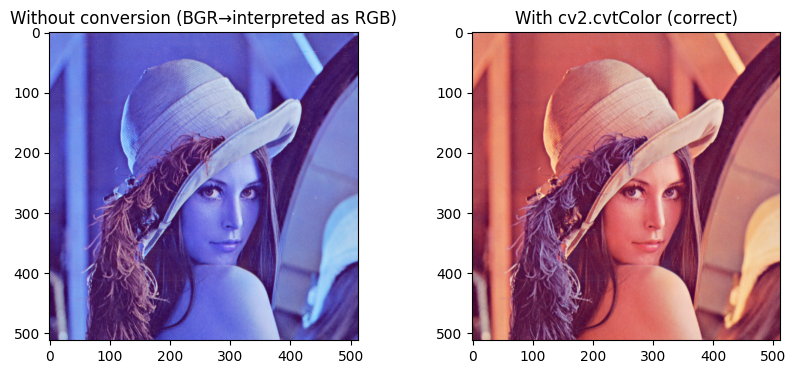

In [ ]:
sample_path = "../resources/images/lenna.png"
img = cv2.imread(sample_path) # Load image (in BGR)
print(f"Image shape: {img.shape}")  # (height, width, channels (BGR))
print(f"Image dtype: {img.dtype}")  # uint8 (0-255); intensity of color in the pixel

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img)  # assumes RGB
axes[0].set_title("Without conversion (BGR→interpreted as RGB)")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convert to RGB
axes[1].imshow(img_rgb)
axes[1].set_title("With cv2.cvtColor (correct)")
plt.show()

### Images Are Arrays of `uint8`

`uint8` stands for **unsigned 8-bit integer**: values in the range [0, 255].

- 0 = no intensity (black for greyscale, no contribution for a colour channel)
- 255 = full intensity (white / saturated channel)

Why 8 bits per channel? One byte per channel is a practical compromise: enough levels (256 per channel = 16.7 M possible colours in RGB) to avoid banding visible to the human eye, without requiring more memory.

This range matters in two practical ways:

1. **Clipping**: values that fall outside the valid image range must be forced back into `[0, 255]`. For example, if an operation produces 300, clipping turns it into 255.
2. **Overflow**: arithmetic done directly in `uint8` can wrap around before you clip. `np.uint8(200) + np.uint8(100)` becomes 44, not 300, because the addition is computed modulo 256.
3. **Neural-network normalisation**: [CLIP](https://openai.com/index/clip/) and most torchvision models expect values in `[0, 1]` (or mean/std normalised). Dividing by `255.0` converts from the OpenCV `uint8` range.

A safe workflow is: convert to `float32` → do the arithmetic → clip to `[0, 255]` → cast back to `uint8`.

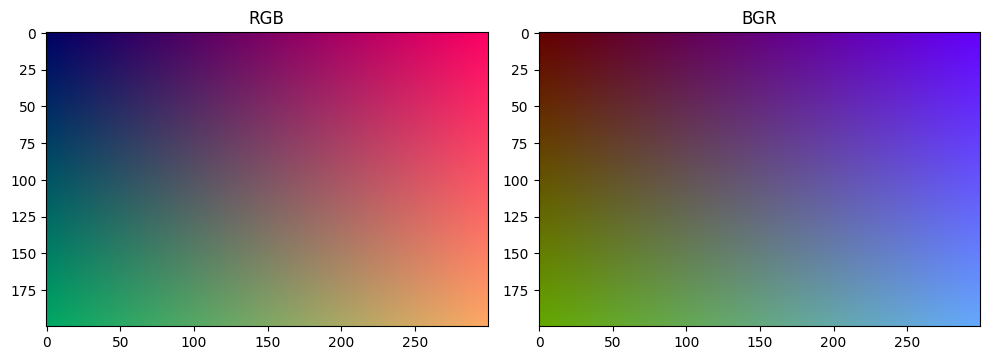

In [ ]:
# Create a simple test image (gradient)
height, width = 200, 300
img_canvas = np.zeros((height, width, 3), dtype=np.uint8) # 3 channel array

# Create RGB gradient (R increases left-right, G increases top-bottom)
for y in range(height):
    for x in range(width):
        img_canvas[y, x] = [int(255 * x / width), # Red
                     int(255 * y / width), # Green
                     100] # Blue


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_canvas)  # assumes RGB
axes[0].set_title("RGB")

img_rgb = cv2.cvtColor(img_canvas, cv2.COLOR_BGR2RGB)

axes[1].imshow(img_rgb)
axes[1].set_title("BGR")
plt.tight_layout()
plt.show()

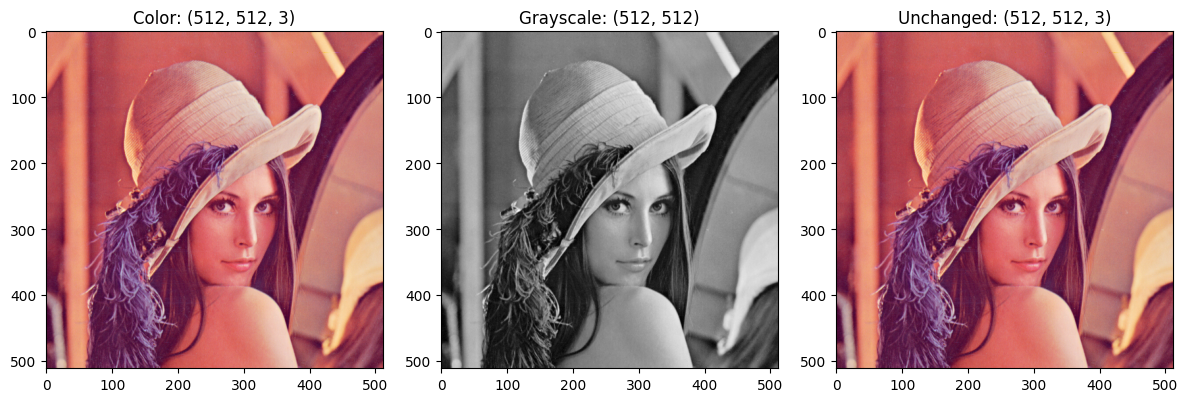

In [ ]:
# Different loading modes.
# cv2.IMREAD_COLOR     (default, 3-channel BGR)
# cv2.IMREAD_GRAYSCALE (1-channel)
# cv2.IMREAD_UNCHANGED (keeps alpha channel if present, e.g. for PNG with transparency)
img_color = cv2.imread(sample_path, cv2.IMREAD_COLOR)
img_gray = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
img_unchanged = cv2.imread(sample_path, cv2.IMREAD_UNCHANGED)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Color: {img_color.shape}")
axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title(f"Grayscale: {img_gray.shape}")
axes[2].imshow(cv2.cvtColor(img_unchanged, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Unchanged: {img_unchanged.shape}")
plt.tight_layout()
plt.show()

## Color Spaces

OpenCV supports many color space conversions:

| Color Space | Use Case |
|-------------|----------|
| **BGR** | Default OpenCV format |
| **RGB** | Display, deep learning |
| **Grayscale** | Edge detection, thresholding |
| **HSV** | Color-based segmentation |
| **LAB** | Perceptually uniform color space |

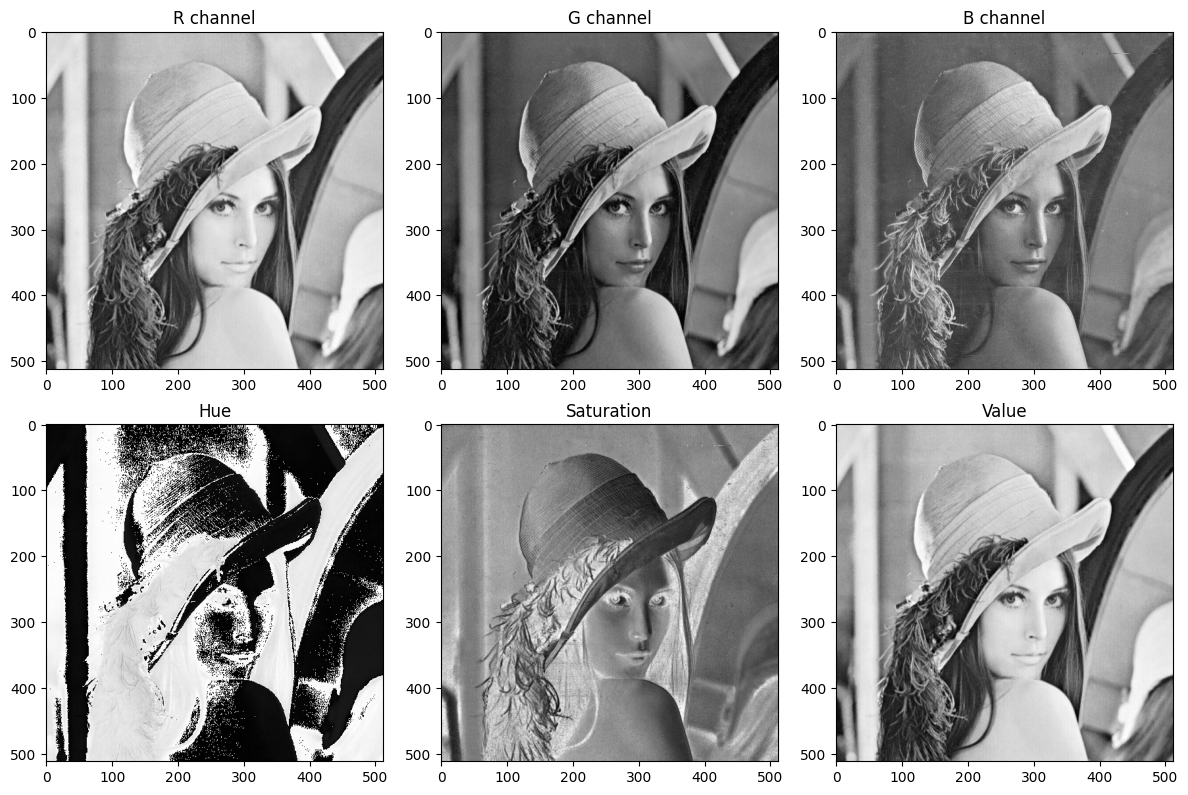

In [ ]:
# Convert to different color spaces
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# RGB channels
for i, (name, channel) in enumerate([('R', img_rgb[:,:,0]), ('G', img_rgb[:,:,1]), ('B', img_rgb[:,:,2])]):
    axes[0, i].imshow(channel, cmap='gray')
    axes[0, i].set_title(f"{name} channel")

# HSV channels
for i, (name, channel) in enumerate([('Hue', img_hsv[:,:,0]), ('Saturation', img_hsv[:,:,1]), ('Value', img_hsv[:,:,2])]):
    axes[1, i].imshow(channel, cmap='gray')
    axes[1, i].set_title(f"{name}")

plt.tight_layout()
plt.show()

## Basic Transformations

### Resizing

### Resizing and Interpolation

Resizing changes the number of pixels in the image. The key decision is not only the new size, but also **how OpenCV invents or merges pixel values** during that change.

Common interpolation choices:

- `INTER_NEAREST`: copies the closest pixel. Fastest, but blocky when enlarging.
- `INTER_LINEAR`: blends nearby pixels. Good default for most everyday resizing.
- `INTER_CUBIC`: uses a wider neighbourhood. Slower, but often smoother for upscaling.
- `INTER_AREA`: averages pixels. Usually the best choice for downscaling because it preserves overall structure and reduces aliasing.

If an enlarged image looks pixelated, that is usually not a bug in `cv2.resize`; it means the method kept hard pixel boundaries visible. That is exactly what `INTER_NEAREST` does, and it is useful when you want to preserve discrete pixels, such as in segmentation masks or pixel art.

Also remember that `cv2.resize` expects size as `(width, height)`, which is the opposite order from a NumPy image shape `(height, width, channels)`.

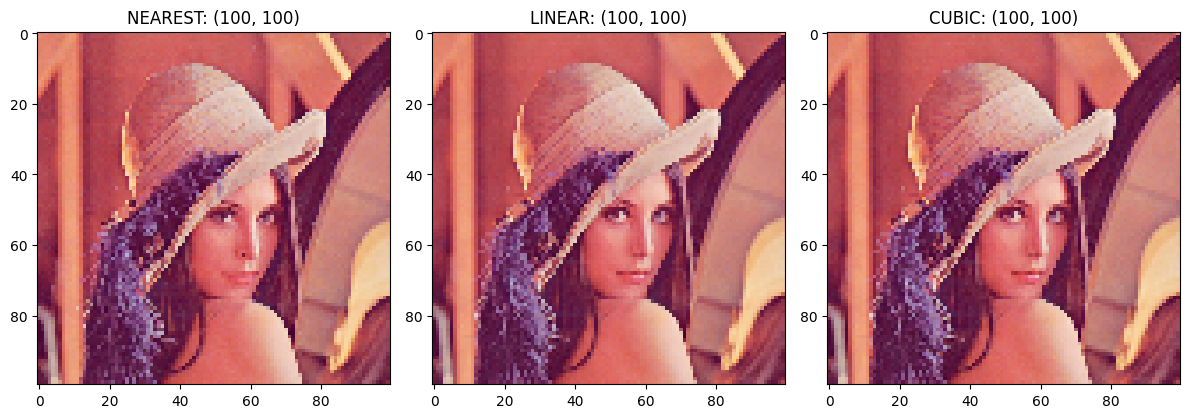

In [ ]:
# Resize by specifying dimensions.
# Note: cv2.resize takes (width, height) — the opposite of NumPy's (rows, cols).
img_small = cv2.resize(img, (100, 100))

# Resize by scale factor
img_half = cv2.resize(img, None, fx=0.5, fy=0.5)

# Interpolation methods control quality vs speed when changing resolution.
# INTER_NEAREST — fastest; good for thumbnails where quality doesn't matter.
# INTER_LINEAR  — bilinear; default; good balance for most cases.
# INTER_CUBIC   — bicubic; sharper upscaling but ~4× slower than LINEAR.
# INTER_AREA    — use when DOWNSCALING; avoids moiré artefacts.
img_nearest = cv2.resize(img, (100, 100), interpolation=cv2.INTER_NEAREST)
img_linear = cv2.resize(img, (100, 100), interpolation=cv2.INTER_LINEAR)
img_cubic = cv2.resize(img, (100, 100), interpolation=cv2.INTER_CUBIC)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, im) in zip(axes, [('NEAREST', img_nearest), ('LINEAR', img_linear), ('CUBIC', img_cubic)]):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{name}: {im.shape[:2]}")
plt.tight_layout()
plt.show()

### Rotation and Flipping

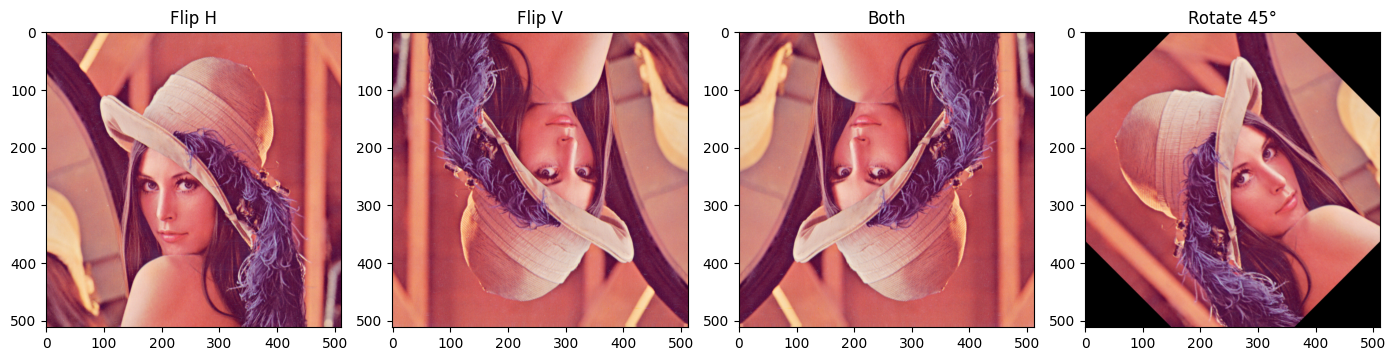

In [ ]:
# Flipping — flip code: 1=horizontal, 0=vertical, -1=both axes
img_flip_h = cv2.flip(img, 1)
img_flip_v = cv2.flip(img, 0)
img_flip_both = cv2.flip(img, -1)

# Rotation requires an affine (2×3) transformation matrix.
# getRotationMatrix2D(center, angle_degrees, scale):
#   angle is counter-clockwise; scale=1.0 keeps the same size.
h, w = img.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, 45, 1.0)

# warpAffine applies M to every pixel.
# The output size (w, h) stays the same — corners that fall outside are clipped.
img_rotated = cv2.warpAffine(img, M, (w, h))

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (name, im) in zip(axes, [('Flip H', img_flip_h), ('Flip V', img_flip_v),
                                   ('Both', img_flip_both), ('Rotate 45°', img_rotated)]):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(name)
plt.tight_layout()
plt.show()

### Cropping

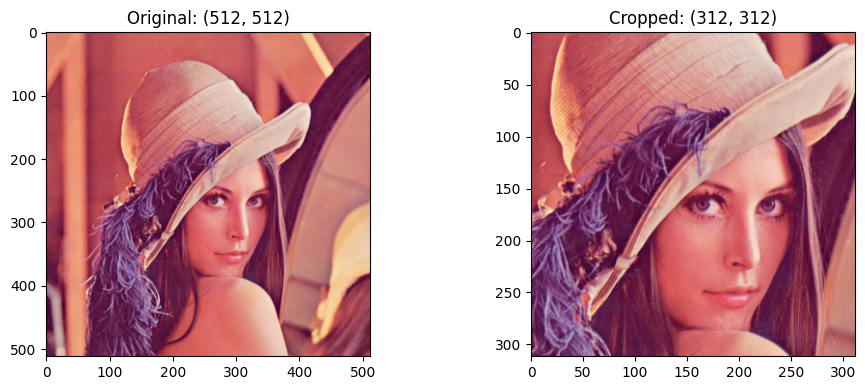

In [ ]:
# Cropping uses NumPy slicing
h, w = img.shape[:2]

# Crop center region
margin = 100
img_cropped = img[margin:h-margin, margin:w-margin]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Original: {img.shape[:2]}")
axes[1].imshow(cv2.cvtColor(img_cropped, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Cropped: {img_cropped.shape[:2]}")
plt.tight_layout()
plt.show()

## Drawing on Images

OpenCV provides functions to draw shapes and text on images.

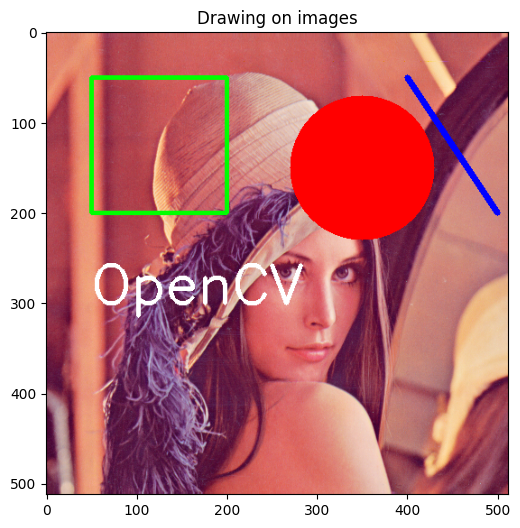

In [ ]:
canvas = img.copy()

# All drawing functions use BGR color tuples and modify the image in-place.
# rectangle(img, pt1_topleft, pt2_bottomright, color_bgr, thickness)
cv2.rectangle(canvas, (50, 50), (200, 200), (0, 255, 0), 3)

# circle(img, center, radius, color_bgr, thickness)
# thickness=-1 fills the shape.
cv2.circle(canvas, (350, 150), 80, (0, 0, 255), -1)

# line(img, pt1, pt2, color_bgr, thickness)
cv2.line(canvas, (400, 50), (500, 200), (255, 0, 0), 5)

# putText(img, text, org_bottomleft, font, fontScale, color, thickness)
cv2.putText(canvas, "OpenCV", (50, 300), cv2.FONT_HERSHEY_SIMPLEX, 2, (255, 255, 255), 3)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title("Drawing on images")
plt.show()

## Saving Images

**JPEG vs PNG:**

- **JPEG** is lossy: it discards information to achieve smaller files (controlled by quality 0–100). At quality 95 the difference is invisible to the eye; at quality 50 artefacts appear around sharp edges. Do not use JPEG for label masks, annotation images, or any image you will process further.
- **PNG** is lossless: every pixel is stored exactly. Files are larger, but no information is lost. Use PNG whenever fidelity matters more than file size.


In [ ]:
import os

output_dir = "../artifacts/outputs"
os.makedirs(output_dir, exist_ok=True)

# Save to different formats
output_jpg = os.path.join(output_dir, "output.jpg")
output_png = os.path.join(output_dir, "output.png")
output_low = os.path.join(output_dir, "output_low.jpg")

cv2.imwrite(output_jpg, img)  # JPEG (lossy)
cv2.imwrite(output_png, img)  # PNG (lossless)

# JPEG quality parameter (0-100)
cv2.imwrite(output_low, img, [cv2.IMWRITE_JPEG_QUALITY, 50])

print("Images saved!")

# Cleanup
for path in [output_jpg, output_png, output_low]:
    if os.path.exists(path):
        os.remove(path)

Images saved!


## Integration with PyTorch

OpenCV is commonly used for loading and preprocessing images before feeding them to neural networks.

There is a direct connection with CNNs, but the roles are different:

- In **classical image processing**, we choose the filter by hand. For example, an edge-detection kernel is designed by us because we already know what pattern we want to highlight.
- In a **convolutional neural network**, the operation is still a convolution, but the kernel values are **learned from data** during training.

So many effects you see in image processing notebooks, such as blurring, sharpening, and edge detection, are built from the same mathematical idea used in convolutional layers. The important difference is that OpenCV filters are fixed tools, while CNN filters are trainable parameters.

In [ ]:
import torch

def preprocess_for_pytorch(img_path, target_size=(224, 224)):
    """Load and preprocess image for PyTorch model."""
    # Load image
    img = cv2.imread(img_path)
    
    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize
    img = cv2.resize(img, target_size)
    
    # Convert to float and normalize to [0, 1]
    img = img.astype(np.float32) / 255.0
    
    # Convert to PyTorch tensor: (H, W, C) → (C, H, W)
    tensor = torch.from_numpy(img).permute(2, 0, 1)
    
    # Add batch dimension: (C, H, W) → (1, C, H, W)
    tensor = tensor.unsqueeze(0)
    
    return tensor

tensor = preprocess_for_pytorch(sample_path)
print(f"Tensor shape: {tensor.shape}")  # (1, 3, 224, 224)
print(f"Tensor dtype: {tensor.dtype}")
print(f"Value range: [{tensor.min():.3f}, {tensor.max():.3f}]")

Tensor shape: torch.Size([1, 3, 224, 224])
Tensor dtype: torch.float32
Value range: [0.012, 1.000]


## Summary

| Operation | Function |
|-----------|----------|
| Load image | `cv2.imread(path, flags)` |
| Save image | `cv2.imwrite(path, img)` |
| Color conversion | `cv2.cvtColor(img, cv2.COLOR_*)` |
| Resize | `cv2.resize(img, (w, h))` |
| Rotate | `cv2.warpAffine(img, M, (w, h))` |
| Flip | `cv2.flip(img, code)` |
| Draw rectangle | `cv2.rectangle(img, pt1, pt2, color, thickness)` |
| Draw circle | `cv2.circle(img, center, radius, color, thickness)` |
| Draw text | `cv2.putText(img, text, org, font, scale, color, thickness)` |